# Pair Traiding 

Asumimos que los precios logarítmicos, $X_t = \ln(P^{(1)}_t)$ and $Y_t = \ln(P^{(2)}_t)$, son caminantes aleatorios. Nuestro trabajo es encontrar el vector cointegrante $(1, -\beta)$ de manera tal que el spread $Z_t$ sea estacionario ($I(0)$):

$$Z_t = Y_t - \beta X_t$$

We model the dynamics of this synthetic observable $Z_t$ as an Ornstein-Uhlenbeck (OU) process, which is the continuous-time analogue of the discrete autoregressive AR(1) model. It represents a particle undergoing Brownian motion under the influence of a harmonic potential well (a spring restoring it to equilibrium).$$dZ_t = \theta (\mu - Z_t)dt + \sigma dW_t$$

Where:
$\theta > 0$ is the rate of mean reversion (the stiffness of the spring).
$\mu$ is the long-term equilibrium mean.
$\sigma$ is the volatility of the stochastic shocks.
$dW_t$ is a standard Wiener process.

- To understand the macroscopic behavior of this system, we do not look at single paths. We look at the evolution of its probability density function $p(z,t)$. In physics, the time evolution of the probability density of an OU process is governed by the Fokker-Planck Equation:$$\frac{\partial p(z,t)}{\partial t} = \frac{\partial}{\partial z} \Big[ \theta(z - \mu) p(z,t) \Big] + \frac{1}{2}\sigma^2 \frac{\partial^2 p(z,t)}{\partial z^2}$$Because the system is mean-reverting, it eventually reaches a thermodynamic equilibrium where $\frac{\partial p}{\partial t} = 0$. Solving the stationary Fokker-Planck equation yields the invariant distribution:$$p_{st}(z) = \sqrt{\frac{\theta}{\pi \sigma^2}} \exp\left( - \frac{\theta}{\sigma^2} (z-\mu)^2 \right)$$This proves that the equilibrium distribution of a cointegrated spread is a Gaussian with mean $\mu$ and variance $\frac{\sigma^2}{2\theta}$. This exact mathematical constraint is what justifies the use of a "Z-score" to define entry and exit thresholds.

## Step 1: Universe Selection via Information Theory. 
Do not use linear correlation to find pairs. Instead, use Mutual Information (MI) to detect both linear and non-linear dependence between the fractional differentials of the price series.$$I(X;Y) = \sum_{y \in Y} \sum_{x \in X} p(x,y) \log \left( \frac{p(x,y)}{p(x)p(y)} \right)$$Filter your universe by selecting pairs with the highest mutual information.


1 Failed download:
['BRK.']: YFTzMissingError('possibly delisted; no timezone found')


Dropped tickers with missing history: ['BRK.']


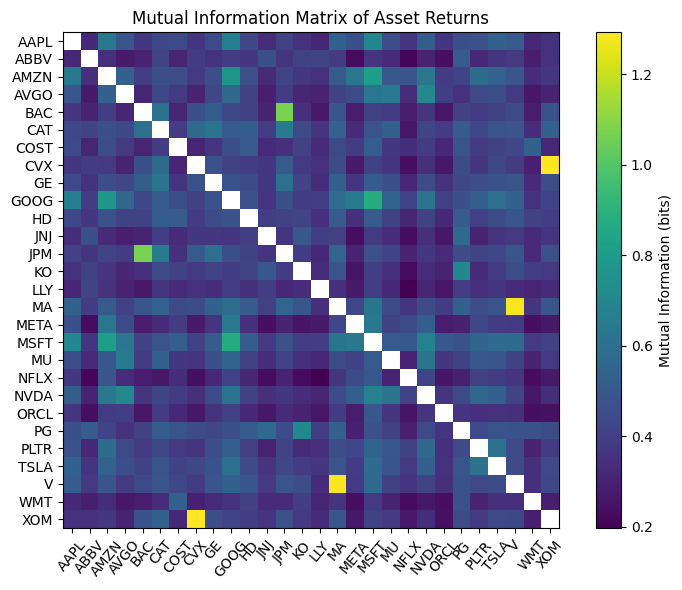

Top 10 Most Coupled Pairs (by Mutual Information):
1. CVX - XOM: 1.2930
2. MA - V: 1.2838
3. BAC - JPM: 1.0737
4. GOOG - MSFT: 0.8756
5. AMZN - MSFT: 0.8120
6. AMZN - GOOG: 0.7756
7. AVGO - NVDA: 0.7138
8. KO - PG: 0.7101
9. AAPL - MSFT: 0.7093
10. MSFT - NVDA: 0.6796


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

def calculate_mi_matrix(returns_df: pd.DataFrame, bins: int = 50) -> pd.DataFrame:
    """
    Computes the pairwise Mutual Information matrix for a universe of asset returns.
    Treats the returns as a complex adaptive system to find non-linear couplings.
    """
    if returns_df is None or returns_df.empty:
        raise ValueError("returns_df is empty. No data available to compute MI.")

    clean_returns = returns_df.dropna(how='any')
    if clean_returns.empty:
        raise ValueError("No overlapping return history after NaN cleaning.")

    assets = clean_returns.columns
    data = clean_returns.values
    n_assets = len(assets)

    mi_matrix = np.full((n_assets, n_assets), np.nan)

    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            x = data[:, i]
            y = data[:, j]

            # Guard against degenerate series
            if np.std(x) == 0 or np.std(y) == 0:
                continue

            cxy, _, _ = np.histogram2d(x, y, bins=bins)
            total = cxy.sum()
            if total == 0:
                continue

            pxy = cxy / total
            px = np.sum(pxy, axis=1)
            py = np.sum(pxy, axis=0)
            px_py = px[:, None] * py[None, :]

            nzs = (pxy > 0) & (px_py > 0)
            if not np.any(nzs):
                continue

            mi = np.sum(pxy[nzs] * np.log2(pxy[nzs] / px_py[nzs]))
            mi_matrix[i, j] = mi
            mi_matrix[j, i] = mi

    return pd.DataFrame(mi_matrix, index=assets, columns=assets)


def get_log_returns(tickers, start_date, end_date):
    """
    Fetches adjusted close prices and computes log returns,
    dropping tickers that failed to download or have no usable history.
    """
    raw = yf.download(
        tickers,
        start=start_date,
        end=end_date,
        auto_adjust=False,
        progress=False,
        threads=True,
    )

    if raw.empty:
        raise ValueError("yfinance returned no data for the requested date range.")

    if isinstance(raw.columns, pd.MultiIndex):
        if 'Adj Close' not in raw.columns.get_level_values(0):
            raise ValueError("'Adj Close' not found in downloaded data.")
        price_data = raw['Adj Close']
    else:
        # Single ticker shape fallback
        price_data = raw.rename(columns={'Adj Close': tickers[0] if isinstance(tickers, list) else tickers})
        if 'Adj Close' in price_data.columns:
            price_data = price_data[['Adj Close']]

    if isinstance(price_data, pd.Series):
        ticker_name = tickers[0] if isinstance(tickers, list) else str(tickers)
        price_data = price_data.to_frame(name=ticker_name)

    valid_cols = [col for col in price_data.columns if price_data[col].notna().sum() > 2]
    dropped_cols = [col for col in price_data.columns if col not in valid_cols]

    if dropped_cols:
        print(f"Dropped tickers with missing history: {dropped_cols}")

    if len(valid_cols) < 2:
        raise ValueError(
            f"Need at least 2 valid tickers to compute MI. Valid tickers found: {valid_cols}"
        )

    price_data = price_data[valid_cols]

    # Keep only overlapping dates for a valid pairwise MI comparison
    log_returns = np.log(price_data / price_data.shift(1)).dropna(how='any')

    if log_returns.empty:
        raise ValueError(
            "No overlapping return observations after cleaning. "
            "Try a later start date or remove sparse tickers."
        )

    return log_returns


# Example usage
tickers = ['NVDA','AAPL','MSFT','AMZN','GOOG','META','AVGO','TSLA','BRK.','WMT','LLY','JPM','XOM','V','JNJ','MU','MA','COST','ORCL','ABBV','NFLX','PG','HD','CVX','BAC','GE','KO','CAT','PLTR']
# tickers = ['NVDA','AAPL','MSFT','AMZN','GOOG','META']

# xle_tickers = [
#     'XOM', 'CVX', 'COP', 'EOG', 'SLB', 'MPC', 'PSX', 'VLO', 'OXY', 'WMB', 
#     'KMI', 'BKR', 'HAL', 'DVN', 'CTRA', 'TRGP', 'FANG', 'MRO', 'APA', 'EQT'
# ]

# # XOP: The Sub-Manifold of Exploration & Production (Equal-Weighted, Highly Volatile)
# # Note: This is a representative subset of the highly liquid E&P components.
# xop_tickers = [
#     'EOG', 'COP', 'DVN', 'OXY', 'FANG', 'MRO', 'APA', 'CIVI', 'MTDR', 
#     'PR', 'MUR', 'SM', 'CHRD', 'MGY', 'CPE', 'AR', 'RRC', 'SWN', 'CNX', 'CRK'
# ]

# Combined Unique Universe for Mutual Information Matrix Calculation
# tickers = list(set(xle_tickers + xop_tickers))

returns_df = get_log_returns(tickers, '2020-01-01', '2026-01-01')
mi_matrix = calculate_mi_matrix(returns_df)

labels = list(mi_matrix.columns)

plt.figure(figsize=(8, 6))
plt.imshow(mi_matrix, cmap='viridis', interpolation='nearest')
plt.colorbar(label='Mutual Information (bits)')
plt.xticks(range(len(labels)), labels, rotation=50)
plt.yticks(range(len(labels)), labels)
plt.title('Mutual Information Matrix of Asset Returns')
plt.tight_layout()
plt.show()

# Select the 10 most coupled pairs based on MI
mi_pairs = []
for i in range(len(mi_matrix)):
    for j in range(i + 1, len(mi_matrix)):
        mi_value = mi_matrix.iloc[i, j]
        if not np.isnan(mi_value):
            mi_pairs.append((mi_matrix.index[i], mi_matrix.columns[j], mi_value))

mi_pairs_sorted = sorted(mi_pairs, key=lambda x: x[2], reverse=True)
top_10_pairs = mi_pairs_sorted[:10]

print("Top 10 Most Coupled Pairs (by Mutual Information):")
for idx, (ticker1, ticker2, mi_value) in enumerate(top_10_pairs, 1):
    print(f"{idx}. {ticker1} - {ticker2}: {mi_value:.4f}")
 



#### Fractional Diferentiation

When you calculate standard log returns, you are applying the first-order difference operator $\Delta X_t = X_t - X_{t-1}$. In signal processing, this acts as a severe high-pass filter. It removes the low-frequency components of the signal—which is exactly where the long-term cointegrating relationship (the "harmonic spring") resides.

Fractional differentiation, introduced to quantitative finance by Marcos López de Prado, applies a fractional filter that makes the series stationary (finite variance, constant mean) while mathematically preserving the low-frequency spectral memory of the underlying price path.

The backshift operator $B$, where $B^k X_t = X_{t-k}$, allows us to define the fractional difference operator for a real number $d$:$$(1-B)^d = \sum_{k=0}^{\infty} \omega_k B^k$$Where the weights $\omega_k$ are derived via the Gamma function:$$\omega_k = (-1)^k \binom{d}{k} = \prod_{i=1}^k \frac{i - 1 - d}{i}$$


In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.feature_selection import mutual_info_regression
import warnings

warnings.filterwarnings("ignore")

def get_ffd_weights(d: float, thres: float) -> np.ndarray:
    """Generates fractional differentiation weights up to a threshold."""
    w, k = [1.], 1
    while True:
        w_ = -w[-1] / k * (d - k + 1)
        if abs(w_) < thres:
            break
        w.append(w_)
        k += 1
    return np.array(w[::-1]).reshape(-1, 1)

def frac_diff_ffd(series: pd.Series, d: float, thres: float = 1e-4) -> pd.Series:
    """Applies Fractional Differentiation (Fixed-Window) to a Pandas Series."""
    w = get_ffd_weights(d, thres)
    width = len(w) - 1
    df_ = pd.Series(index=series.index, dtype=float)
    
    # Vectorized dot product over a rolling window
    for i in range(width, len(series)):
        window = series.iloc[i - width : i + 1].values
        if np.isfinite(window).all():
            df_.iloc[i] = np.dot(w.T, window)[0]
            
    return df_.dropna()

# 1. Fetch Data
print("Fetching KO and PEP daily log-prices...")
data = yf.download(['KO', 'PEP'], start='2015-01-01', end='2024-01-01', auto_adjust=False)['Adj Close']
log_prices = np.log(data).dropna()

# 2. Integer Differentiation (Log Returns, d=1)
returns = log_prices.diff().dropna()

# 3. Fractional Differentiation (d=0.4)
# Note: In production, d must be dynamically optimized via ADF test. 0.4 is chosen heuristically here.
print("Applying Fractional Differentiation (d=0.4)...")
frac_diff_KO = frac_diff_ffd(log_prices['KO'], d=0.4)
frac_diff_PEP = frac_diff_ffd(log_prices['PEP'], d=0.4)

# Align the fractionally differenced series
frac_diff_df = pd.concat([frac_diff_KO, frac_diff_PEP], axis=1).dropna()
frac_diff_df.columns = ['KO', 'PEP']

# 4. Calculate Mutual Information (KSG Estimator)
# We calculate MI(X, Y) using k=3 nearest neighbors
mi_returns = mutual_info_regression(returns[['KO']].values, returns['PEP'].values, n_neighbors=3, random_state=42)[0]
mi_frac = mutual_info_regression(frac_diff_df[['KO']].values, frac_diff_df['PEP'].values, n_neighbors=3, random_state=42)[0]

print("-" * 50)
print(f"Mutual Information (Log Returns, d=1.0):      {mi_returns:.4f} nats")
print(f"Mutual Information (Frac. Differenced, d=0.4): {mi_frac:.4f} nats")
print(f"Information Gained by Preserving Memory:       {((mi_frac - mi_returns) / mi_returns) * 100:.2f}%")
print("-" * 50)

Fetching KO and PEP daily log-prices...


[*********************100%***********************]  2 of 2 completed


Applying Fractional Differentiation (d=0.4)...
--------------------------------------------------
Mutual Information (Log Returns, d=1.0):      0.4666 nats
Mutual Information (Frac. Differenced, d=0.4): 0.6426 nats
Information Gained by Preserving Memory:       37.71%
--------------------------------------------------


#### Probabilidad conjunta

Observamos que según la derivada aplicada, cambia la estructura de la distribución de probabilidad.

A ambos pares de variables le realizamos una transformación y analizamos el Z-score.

$$z_t = \frac{\tilde{X}_t - \text{E}[\tilde{X}]}{\sqrt{\text{Var}(\tilde{X})}}$$

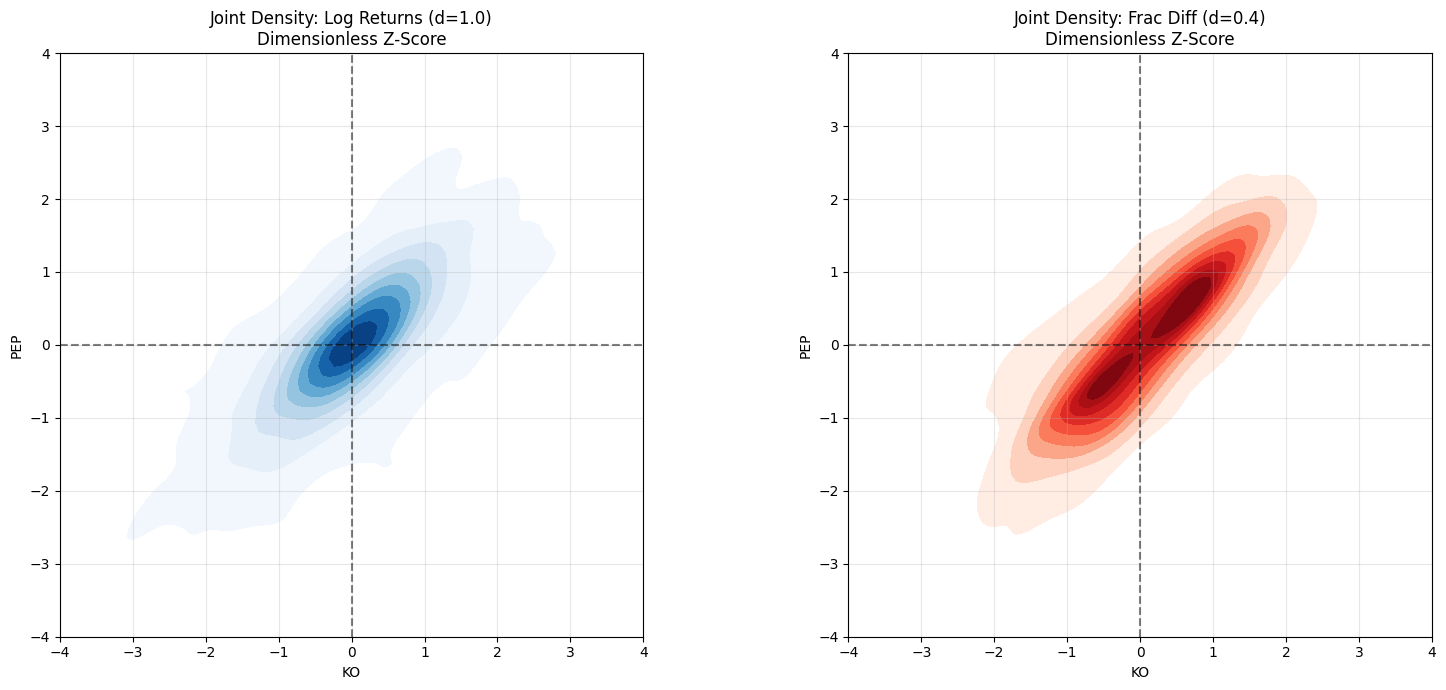

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import StandardScaler

def visualize_mi_manifold_zscored(df_returns, df_frac, pair=('KO', 'PEP')):
    """
    Diagnostic tool to compare the information density of returns vs fractional diff,
    using dimensionless Z-scores to ensure an unbiased topological representation.
    """
    # 1. Initialize the Standard Scaler
    scaler = StandardScaler()
    
    # Extract the pair and drop NaNs to avoid scaler errors
    data_returns = df_returns[list(pair)].dropna()
    data_frac = df_frac[list(pair)].dropna()
    
    # 2. Calculate Z-scores for Log Returns
    returns_scaled = scaler.fit_transform(data_returns)
    df_returns_z = pd.DataFrame(returns_scaled, columns=pair, index=data_returns.index)
    
    # 3. Calculate Z-scores for Fractionally Differenced Prices
    frac_scaled = scaler.fit_transform(data_frac)
    df_frac_z = pd.DataFrame(frac_scaled, columns=pair, index=data_frac.index)

    # 4. Create the Diagnostic Dashboard
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # --- Plot 1: Log Returns (Z-Scored) ---
    sns.kdeplot(data=df_returns_z, x=pair[0], y=pair[1], ax=axes[0], 
                cmap="Blues", fill=True, thresh=0.05, 
                bw_method='silverman')  # Enforce objective bandwidth selection
    
    
    # Force 1:1 aspect ratio to prevent optical distortion
    axes[0].set_aspect('equal', adjustable='box')
    axes[0].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
    axes[0].set_title(f"Joint Density: Log Returns (d=1.0)\nDimensionless Z-Score")
    axes[0].grid(alpha=0.3)
    axes[0].set_xlim(-4, 4)
    axes[0].set_ylim(-4, 4)

    
    # --- Plot 2: Fractional Differentiation (Z-Scored) ---
    sns.kdeplot(data=df_frac_z, x=pair[0], y=pair[1], ax=axes[1], 
                cmap="Reds", fill=True, thresh=0.05, 
                bw_method='silverman')
    
    # Force 1:1 aspect ratio
    axes[1].set_aspect('equal', adjustable='box')
    axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
    axes[1].axvline(0, color='black', linestyle='--', alpha=0.5)
    axes[1].set_title(f"Joint Density: Frac Diff (d=0.4)\nDimensionless Z-Score")
    axes[1].grid(alpha=0.3)
    axes[1].set_xlim(-4, 4)
    axes[1].set_ylim(-4, 4)
    
    plt.tight_layout()
    plt.show()

# Usage Example:
visualize_mi_manifold_zscored(returns, frac_diff_df, pair=('KO', 'PEP'))


####  Hedge Ratio ($\beta$)

Realizamos la regresión lineal (OLS) sobre el modelo:

$$ \log A_t= \beta \log B_t + \alpha + \epsilon_t$$

Para comprobar estacionariedad, le realizamos el test aumentado de Dickey-Fuller (ADF). It is a statistical test used to determine whether a time series contains a "unit root" (meaning it is a non-stationary random walk) or if it is stationary (meaning it reverts to a stable equilibrium).

The full equation for the Augmented Dickey-Fuller test is:$$\Delta y_t = \alpha + \beta t + \gamma y_{t-1} + \sum_{i=1}^p \delta_i \Delta y_{t-i} + \epsilon_t$$Where:$\alpha$ is a constant (drift).$\beta t$ is a deterministic time trend.$y_{t-1}$ is the lagged level of the series.$\gamma$ is the critical parameter representing the restoring force.$\sum_{i=1}^p \delta_i \Delta y_{t-i}$ are the "augmented" lagged difference terms, added to absorb any serial correlation in the error term $\epsilon_t$.

Descargando YPF y PAM...


[*********************100%***********************]  2 of 2 completed


Hedge Ratio (Beta): 1.5556
R-squared: 0.9511
ADF Statistic: -2.3756
p-value: 0.1487
ALERTA: El spread NO es estacionario


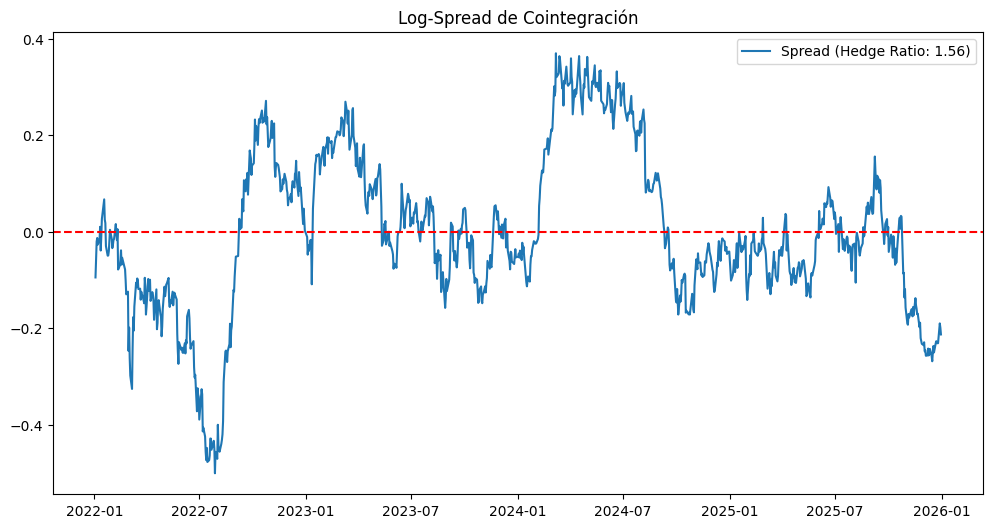

In [27]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
import matplotlib.pyplot as plt

def extract_and_construct_spread(ticker_A, ticker_B, start_date, end_date):
    """
    Descarga datos, calcula el Hedge Ratio via OLS y construye el Spread.
    
    Args:
        ticker_A (str): Ticker del activo dependiente (ej. 'GLD').
        ticker_B (str): Ticker del activo independiente (ej. 'GDX').
        start_date (str): Fecha inicio 'YYYY-MM-DD'.
        end_date (str): Fecha fin 'YYYY-MM-DD'.
        
    Returns:
        pd.Series: El spread histórico (z-score).
        float: El Hedge Ratio (beta).
    """
    
    # 1. Descarga de datos (Solo 'Adj Close' para ajustar por dividendos/splits)
    print(f"Descargando {ticker_A} y {ticker_B}...")
    data = yf.download([ticker_A, ticker_B], start=start_date, end=end_date, auto_adjust=False)['Adj Close']
    
    # Limpieza de datos (eliminar filas con NaN)
    data = data.dropna()
    
    if data.empty:
        raise ValueError("No se descargaron datos. Verifica los tickers o fechas.")

    # 2. Convertir a Log-Precios
    # Usamos log natural
    log_A = np.log(data[ticker_A])
    log_B = np.log(data[ticker_B])
    
    # 3. Calcular Hedge Ratio (Beta) usando OLS (Mínimos Cuadrados Ordinarios)
    # Ecuación: log_A = beta * log_B + alpha + error
    # Añadimos una constante (intercepto/alpha) a la regresión
    X = sm.add_constant(log_B)
    model = sm.OLS(log_A, X).fit()
    
    alpha = model.params['const']
    beta = model.params[ticker_B]
    
    print(f"Hedge Ratio (Beta): {beta:.4f}")
    print(f"R-squared: {model.rsquared:.4f}")
    
    # 4. Construir el Spread Bruto
    # spread = y - (beta * x + alpha)
    # Nota: En trading real, a veces ignoramos alpha y solo operamos A - beta*B
    # Pero para el modelo OU riguroso, usamos el residuo completo.
    raw_spread = log_A - (beta * log_B + alpha)
    
    # 5. Test de Estacionariedad (ADF Test)
    # El spread DEBE ser estacionario para que funcione el par.
    adf_result = adfuller(raw_spread)
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"p-value: {adf_result[1]:.4f}")
    
    if adf_result[1] > 0.05:
        print("ALERTA: El spread NO es estacionario")
    else:
        print("ÉXITO: El spread es estacionario.")

    return raw_spread, beta

# --- EJECUCIÓN ---
# Ejemplo clásico: Oro (GLD) vs Mineras de Oro (GDX)
# Nota: En 2026 este par está muy arbitrado, pero sirve de ejemplo académico.
try:
    spread_series, hedge_ratio = extract_and_construct_spread('YPF', 'PAM', '2022-01-01', '2026-01-01')

    # Visualización rápida
    plt.figure(figsize=(12, 6))
    plt.plot(spread_series, label=f'Spread (Hedge Ratio: {hedge_ratio:.2f})')
    plt.axhline(spread_series.mean(), color='red', linestyle='--')
    plt.title('Log-Spread de Cointegración')
    plt.legend()
    plt.show()
    
except Exception as e:
    print(f"Error: {e}")

#### Proceso de Ornstein Ulenbeck

Ajustamos el siguiente modelo de Ornstein Ulenbeck a nuestro spread. Debemos usar la solución para tiempo discreto $\Delta t$:

$$ Z_t = Z_{t-1}e^{-\theta \Delta t} + \mu (1- e^{-\theta \Delta t}) + \epsilon_t$$

$$\text{Var}(\epsilon_t) = \sigma^2 \frac{1 - e^{-2\theta \Delta t}}{2\theta}$$

In [9]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

def fit_ou_process(spread: pd.Series, dt: float = 1.0) -> dict:
    """
    Fits an Ornstein-Uhlenbeck process to a stationary discrete time series.
    
    Parameters:
    spread (pd.Series): The stationary spread Z_t.
    dt (float): The time step (default is 1.0 for daily data to get half-life in days).
    
    Returns:
    dict: The continuous-time OU parameters (theta, mu, sigma) and the half-life.
    """
    # 1. Prepare the lagged data for AR(1) regression
    y = spread.values[1:]          # Z_t
    x = spread.values[:-1]         # Z_{t-1}
    
    # 2. Add intercept for the OLS regression (a + b * Z_{t-1})
    X = sm.add_constant(x)
    
    # 3. Fit the Ordinary Least Squares (OLS) model
    ols_model = sm.OLS(y, X).fit()
    a, b = ols_model.params
    
    # Calculate the variance of the residuals
    var_epsilon = np.var(ols_model.resid, ddof=2)
    
    # 4. Map discrete AR(1) parameters to continuous OU parameters
    # If b >= 1, the series is NOT stationary (unit root or explosive).
    if b >= 1:
        raise ValueError("The AR(1) coefficient is >= 1. The spread is not stationary. Check your ADF test.")
    if b <= 0:
        raise ValueError("The AR(1) coefficient is <= 0. The series oscillates deterministically.")
        
    theta = -np.log(b) / dt
    mu = a / (1 - b)
    sigma = np.sqrt((2 * theta * var_epsilon) / (1 - b**2))
    
    # 5. Calculate Half-Life
    half_life = np.log(2) / theta
    
    # 6. Calculate the equilibrium Z-score boundaries
    # The equilibrium standard deviation of the spread is NOT the sample standard deviation.
    # It is derived from the OU parameters: sigma_eq = sqrt(sigma^2 / 2*theta)
    sigma_eq = np.sqrt((sigma**2) / (2 * theta))
    
    return {
        'theta': theta,
        'mu': mu,
        'sigma': sigma,
        'half_life': half_life,
        'sigma_eq': sigma_eq,
        'r_squared': ols_model.rsquared
    }

# --- Usage Example ---
# Assuming `Z_t` is a pandas Series of your fractionally differenced, cointegrated spread.
ou_params = fit_ou_process(spread_series, dt=1.0)
print(f"Mean Reversion Rate (Theta): {ou_params['theta']:.4f}")
print(f"Equilibrium Mean (Mu):       {ou_params['mu']:.4f}")
print(f"Half-Life (days):            {ou_params['half_life']:.2f}")

# Calculate dimensionless z-score for trading execution:
z_score_t = (spread_series.iloc[-1] - ou_params['mu']) / ou_params['sigma_eq']

Mean Reversion Rate (Theta): 0.0257
Equilibrium Mean (Mu):       0.0003
Half-Life (days):            27.00


- Set a maximum holding period based on the half-life. A common heuristic in the literature (e.g., Vidyamurthy) is:$$T_{max} = 2 \times t_{1/2}$$If the spread has not reverted by $T_{max}$, the "spring" is likely broken (a structural break has occurred). Holding further increases your exposure to the "First-Passage to Infinity" (divergence).

- The Sharpe Ratio Maximization:The annualized Sharpe Ratio of a mean-reverting strategy is a function of $\theta$. Higher $\theta$ (shorter half-life) allows for more "round-trips" per year, increasing the numerator of the Sharpe Ratio.$$\text{Expected Annual Trades} \approx \frac{252}{t_{1/2} + \text{Wait Time}}$$

[*********************100%***********************]  2 of 2 completed


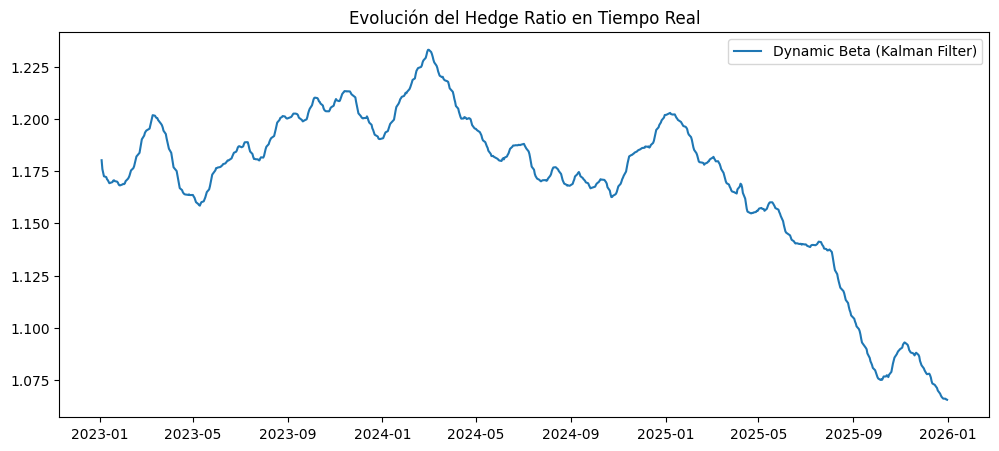

In [38]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

def kalman_filter_pair_trading(ticker_A, ticker_B, start, end):
    # 1. Obtención de datos
    data = yf.download([ticker_A, ticker_B], start=start, end=end, auto_adjust=False)['Adj Close'].dropna()
    x = np.log(data[ticker_B].values)
    y = np.log(data[ticker_A].values)

    # 2. Inicialización de variables del Filtro de Kalman
    # Estado inicial [beta, alpha]
    state_means = np.zeros(2)
    # Incertidumbre inicial (Covarianza del estado)
    state_cov = np.ones((2, 2))
    
    # Parámetros de ruido (Hiperparámetros)
    # Q: Covarianza del proceso (qué tan rápido cambian beta y alpha)
    # R: Covarianza de la medición (ruido en los precios)
    Q = 1e-5 * np.eye(2)
    R = 0.01
    
    betas = []
    alphas = []
    spreads = []

    # 3. Bucle del Filtro (Online Learning)
    for t in range(len(y)):
        # --- PASO DE PREDICCIÓN ---
        # El estado esperado es igual al anterior (Paseo Aleatorio)
        # La covarianza aumenta por el ruido del proceso Q
        state_cov = state_cov + Q
        
        # --- PASO DE ACTUALIZACIÓN ---
        # Vector de observación H (los datos del activo B hoy)
        H = np.array([x[t], 1.0])
        
        # Innovación (Error de predicción)
        prediction = np.dot(H, state_means)
        innovation = y[t] - prediction
        
        # Covarianza de la innovación
        innovation_cov = np.dot(H, np.dot(state_cov, H.T)) + R
        
        # Ganancia de Kalman (K)
        K = np.dot(state_cov, H.T) / innovation_cov
        
        # Actualizar estado e incertidumbre
        state_means = state_means + K * innovation
        state_cov = state_cov - np.outer(K, np.dot(H, state_cov))
        
        # Guardar resultados
        betas.append(state_means[0])
        alphas.append(state_means[1])
        spreads.append(innovation) # El spread es la innovación/error

    # 4. Resultados
    results = pd.DataFrame(index=data.index)
    results['beta'] = betas
    results['alpha'] = alphas
    results['spread'] = spreads
    
    return results

# Ejecución
kf_results = kalman_filter_pair_trading('GLD', 'GDX', '2023-01-01', '2026-01-01')

# Visualización del Hedge Ratio Dinámico
plt.figure(figsize=(12, 5))
plt.plot(kf_results['beta'], label='Dynamic Beta (Kalman Filter)')
plt.title('Evolución del Hedge Ratio en Tiempo Real')
plt.legend()
plt.show()

In [39]:
import numpy as np
import pandas as pd
import yfinance as yf
import statsmodels.api as sm

def backtest_pair_trading(ticker_A, ticker_B, start, end, window=60, entry_z=2.0, exit_z=0, cost=0.001):
    # 1. Descarga y preparación
    data = yf.download([ticker_A, ticker_B], start=start, end=end, auto_adjust=False)['Adj Close'].dropna()
    log_prices = np.log(data)
    
    # DataFrame para resultados
    results = pd.DataFrame(index=log_prices.index)
    results['log_A'] = log_prices[ticker_A]
    results['log_B'] = log_prices[ticker_B]
    
    #Use kalman filter para obtener beta dinámico
    kf_results = kalman_filter_pair_trading(ticker_A, ticker_B, start, end)
    betas = kf_results['beta'].values
    spreads = kf_results['spread'].values

    results['beta'] = betas
    results['spread'] = spreads
    
    # 3. Normalización (Z-Score)
    results['mean'] = results['spread'].rolling(window=window).mean()
    results['std'] = results['spread'].rolling(window=window).std()
    results['z_score'] = (results['spread'] - results['mean']) / results['std']
    
    # 4. Lógica de Trading (Vectorizada)
    # Posición: 1 (Long Spread), -1 (Short Spread), 0 (Neutral)
    results['position'] = 0
    curr_pos = 0
    positions = []
    
    for z in results['z_score']:
        if np.isnan(z):
            positions.append(0)
            continue
        
        if curr_pos == 0:
            if z > entry_z: curr_pos = -1 # Short A, Long B
            elif z < -entry_z: curr_pos = 1 # Long A, Short B
        elif curr_pos == 1 and z >= exit_z:
            curr_pos = 0 # Cerrar Long
        elif curr_pos == -1 and z <= exit_z:
            curr_pos = 0 # Cerrar Short
            
        positions.append(curr_pos)
    
    results['position'] = positions
    
    # 5. Cálculo de Retornos
    # Retorno del spread = d(Spread)
    # Nota: Simplificación para propósitos académicos
    results['returns_A'] = results['log_A'].diff()
    results['returns_B'] = results['log_B'].diff()
    
    # Retorno estrategia = Posicion_t-1 * (Ret_A - Beta * Ret_B)
    results['strategy_ret'] = results['position'].shift(1) * (results['returns_A'] - results['beta'] * results['returns_B'])
    
    # Aplicar costes de transacción (cuando la posición cambia)
    trades = results['position'].diff().fillna(0) != 0
    results['strategy_ret'] = results['strategy_ret'] - (trades * cost)
    
    # 6. Métricas
    cum_ret = results['strategy_ret'].cumsum().apply(np.exp)
    sharpe = (results['strategy_ret'].mean() / results['strategy_ret'].std()) * np.sqrt(252)
    
    return results, sharpe, cum_ret

# Ejemplo práctico
res, sharpe, equity = backtest_pair_trading('KO', 'PEP', '2001-01-01', '2002-01-01')
print(f"Sharpe Ratio del Backtest: {sharpe:.2f}")

[*********************100%***********************]  2 of 2 completed
[*********************100%***********************]  2 of 2 completed

Sharpe Ratio del Backtest: 0.19
